In [11]:
import polars as pl
import polars_bio as pb
import cooler

from cooler.core import (
    CSRReader,
    DirectRangeQuery2D
)
import matplotlib.pyplot as plt
import pandas as pd

import numpy as np

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import zoom
import itertools as it
from pairtools.lib.pairsio import read_pairs

from dataclasses import dataclass
from scipy.sparse import coo_matrix, csr_matrix

In [12]:
from lib import read_chain_file

from src.readers import ChainReader, CoolerPolars, read_cooler, read_pairs, read_cooler_square, read_cooler_chunk
from src.transformers import remap_bins

from src.pixel_dividers import LinearDivider, CVDNorm

from src._utils import POLARS_VMAX

/Users/egorpitikov/Documents/pets/liftover_2d/.venv/lib/python3.12/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [53]:
COOLER_PATH = '/Users/egorpitikov/Downloads/4DNFIZ1ZVXC8.mcool'
RESOLUTION = 10_000
CHAIN_PATH = '/Users/egorpitikov/Downloads/dm3ToDm6.over.chain'

In [14]:
clr = cooler.Cooler(f'{COOLER_PATH}::resolutions/{RESOLUTION}')

In [15]:
a = ChainReader(open(CHAIN_PATH, 'rb'))

In [16]:
for bbox, tttt in read_cooler_square(clr):
    break

In [17]:
bbox

(0, 700, 0, 700)

In [17]:
tttt.counts['bin1_id'].to_numpy()

array([  0,   0,   0, ..., 698, 698, 699], shape=(204412,), dtype=uint64)

In [36]:
def reflect_window_keep_diag(csr_window):
    diag = csr_matrix(csr_window.diagonal().reshape(-1, 1))
    to_add = csr_window.T
    to_add.setdiag(0)
    return csr_window + to_add

In [37]:
sparse_csr = csr_matrix(
    (
        tttt.counts['count'].to_numpy(), 
        (tttt.counts['bin1_id'].to_numpy(), tttt.counts['bin2_id'].to_numpy())
    ), 
    shape=(tttt.n_bins, tttt.n_bins)
)

sparse_csr = reflect_window_keep_diag(sparse_csr)
sparse_csr = sparse_csr[bbox[0]:bbox[1], bbox[2]:bbox[3]]

In [57]:
def calculate_small_window(bin1, bin2, sparse_contacts, window_size, bbox):
    loc_hor = bin1 - bbox[0]
    loc_ver = bin2 - bbox[2]

    start_i = max(0, loc_hor - window_size)
    end_i   = min(sparse_contacts.shape[0], loc_hor + window_size + 1)
    start_j = max(0, loc_ver - window_size)
    end_j   = min(sparse_contacts.shape[1], loc_ver + window_size + 1)
    
    window = sparse_contacts[start_i:end_i, start_j:end_j]
    location_in_window = (loc_hor - start_i, loc_ver - start_j)
    
    return window.toarray(), location_in_window

def process_one_window(counts_arr, location, scale_factor=5, k=5):
    zoomed = zoom(counts_arr, zoom=scale_factor, order=k, grid_mode=True, mode='nearest')
    our_pixel = zoomed[
        location[0]*scale_factor:(location[0]+1)*scale_factor, 
        location[1]*scale_factor:(location[1]+1)*scale_factor, 
    ]
    our_pixel = np.clip(our_pixel, 0, None)
    our_pixel = our_pixel.astype(np.float64)
    s = our_pixel.sum()
    if s > 0:
        our_pixel /= s
    return our_pixel

def calculate_one_pixel(sourse, region_in_rate_1, region_in_rate_2, scale_factor) -> float:
        minimal_divider = 1/scale_factor
        # (x + y/2)//y = math rounded locartion
        slice_bin_1_start = int((region_in_rate_1[0] + 0.5*minimal_divider)//minimal_divider)
        slice_bin_1_end = int((region_in_rate_1[1] + 0.5*minimal_divider)//minimal_divider)

        slice_bin_2_start = int((region_in_rate_2[0] + 0.5*minimal_divider)//minimal_divider)
        slice_bin_2_end = int((region_in_rate_2[1] + 0.5*minimal_divider)//minimal_divider)
 
        weight = sourse[slice_bin_1_start:slice_bin_1_end, slice_bin_2_start:slice_bin_2_end].sum()

        print(sourse[slice_bin_1_start:slice_bin_1_end, slice_bin_2_start:slice_bin_2_end])
        return weight

In [63]:
for row in tttt.counts.select(
    pl.col('bin1_id'), 
    pl.col('bin2_id'),
    pl.concat_list(list(np.sort(np.random.random(2)))).alias("source_bin_location_2"),
    pl.concat_list(list(np.sort(np.random.random(2)))).alias("source_bin_location_1")
).iter_rows(named=True):
    window, location = calculate_small_window(
        row['bin1_id'], 
        row['bin2_id'], 
        sparse_csr, 
        5, 
        bbox
    )
    weights = process_one_window(window, location, scale_factor=5, k=5)
    res = calculate_one_pixel(
        weights,
        row['source_bin_location_1'], 
        row['source_bin_location_2'], 
        scale_factor=5
    )
    print(weights, res)
    break


[[0.03034376 0.03160639 0.03553682 0.04176849]
 [0.03519062 0.03679945 0.04176849 0.04973118]]
[[0.02627077 0.02726865 0.03034376 0.03519062 0.04079097]
 [0.02726865 0.028348   0.03160639 0.03679945 0.0428071 ]
 [0.03034376 0.03160639 0.03553682 0.04176849 0.04903877]
 [0.03519062 0.03679945 0.04176849 0.04973118 0.05903796]
 [0.04079097 0.0428071  0.04903877 0.05903796 0.0708089 ]] 0.30274519387422616


In [ ]:
for (bin1, bin2, count) in tttt.counts.iter_rows():
    mat, loc = calculate_small_window(bin1, bin2, sparse_csr, 20, bbox)
    print(mat)
    break

[[ 1745  2844   409   195   195   167   144   112    94    69    74    62
     65    54    44    39    18    23    13    12    28]
 [    0  5719  1815   710   538   417   419   283   237   159   164   108
    136   124    80    82    50    53    38    29    59]
 [    0     0  4141  3479  2054  1186   684   318   244   164   147   113
    107   100    69    71    39    41    21    28    49]
 [    0     0     0  2974  2750  1368   651   291   226   140   128    79
     97    85    65    50    20    35    21    29    44]
 [    0     0     0     0  3620  3533  1401   589   364   194   188   141
     92   148    90    72    43    39    18    27    36]
 [    0     0     0     0     0  3661  3303   962   554   267   201   159
    135   175   104    68    41    51    25    25    37]
 [    0     0     0     0     0     0  5656  3373  1242   501   458   273
    253   288   117   117    55    62    41    39    73]
 [    0     0     0     0     0     0     0  5480  4913  1179   884   470
    405  

In [11]:
tttt.counts

bin1_id,bin2_id,count
u64,u64,u64
0,0,1745
0,1,2844
0,2,409
0,3,195
0,4,195
…,…,…
697,698,1398
697,699,247
698,698,1740


In [ ]:
from scipy import coo

In [7]:
remap_matrix = remap_bins(
    source=b,
    target=b,
    chains=a
)

NameError: name 'b' is not defined

In [14]:
remap_matrix

source_bin,source_bin_chrom,source_bin_location,source_bin_region,target_bin,target_bin_chrom,target_bin_location,target_bin_region
u64,str,list[u64],list[u64],u64,str,list[u64],list[u64]
0,"""chr2L""","[0, 10000]","[0, 10000]",0,"""chr2L""","[0, 10000]","[0, 10000]"
2300,"""chr2L""","[23000000, 23010000]","[23004078, 23004135]",0,"""chr2L""","[0, 10000]","[595, 652]"
2300,"""chr2L""","[23000000, 23010000]","[23000773, 23000850]",0,"""chr2L""","[0, 10000]","[1692, 1769]"
2300,"""chr2L""","[23000000, 23010000]","[23003882, 23003950]",0,"""chr2L""","[0, 10000]","[2205, 2273]"
1,"""chr2L""","[10000, 20000]","[10000, 10000]",0,"""chr2L""","[0, 10000]","[10000, 10000]"
…,…,…,…,…,…,…,…
13276,"""chrX""","[22400000, 22410000]","[22401836, 22410000]",13336,"""chrX""","[23000000, 23010000]","[23000000, 23008164]"
13277,"""chrX""","[22410000, 22420000]","[22410000, 22411836]",13336,"""chrX""","[23000000, 23010000]","[23008164, 23010000]"
13277,"""chrX""","[22410000, 22420000]","[22411836, 22420000]",13337,"""chrX""","[23010000, 23020000]","[23010000, 23018164]"


In [15]:
a.blocks

name_chain_source,start_aln_source,end_aln_source,strand_chain_source,name_chain_target,start_aln_target,end_aln_target,strand_chain_target,size_aln,start_chain_source,end_chain_source,size_chain_source,start_chain_target,end_chain_target,size_chain_target,score,index_chain,index_chain_block
str,u64,u64,str,str,u64,u64,str,u64,u64,u64,u64,u64,u64,u64,u64,u64,u64
"""chr2L""",0,22420241,"""+""","""chr2L""",0,22420241,"""+""",22420241,0,23011314,23011544,0,23112624,23513712,2179801675,3,0
"""chr2L""",22420341,22990368,"""+""","""chr2L""",22527609,23097636,"""+""",570027,0,23011314,23011544,0,23112624,23513712,2179801675,3,0
"""chr2L""",22990369,22991634,"""+""","""chr2L""",23097636,23098901,"""+""",1265,0,23011314,23011544,0,23112624,23513712,2179801675,3,0
"""chr2L""",22991635,22992682,"""+""","""chr2L""",23098901,23099948,"""+""",1047,0,23011314,23011544,0,23112624,23513712,2179801675,3,0
"""chr2L""",22992683,22994001,"""+""","""chr2L""",23099948,23101266,"""+""",1318,0,23011314,23011544,0,23112624,23513712,2179801675,3,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chrYHet""",346935,347038,"""+""","""chr3L""",3143324,3143427,"""-""",103,346819,347038,347038,3143213,3143427,28110227,1017,59509,60362
"""chrYHet""",310516,310574,"""+""","""chrUn_DS485357v1""",329,387,"""-""",58,310516,310656,347038,329,469,1159,728,317421,60363
"""chrYHet""",310628,310656,"""+""","""chrUn_DS485357v1""",441,469,"""-""",28,310516,310656,347038,329,469,1159,728,317421,60363


In [16]:
a.chains

title,score,name_chain_source,size_chain_source,strand_chain_source,start_chain_source,end_chain_source,name_chain_target,size_chain_target,strand_chain_target,start_chain_target,end_chain_target,index_chain,index_chain_block
str,u64,str,u64,str,u64,u64,str,u64,str,u64,u64,u64,u64
"""chain""",2179801675,"""chr2L""",23011544,"""+""",0,23011314,"""chr2L""",23513712,"""+""",0,23112624,3,0
"""chain""",110008,"""chr2L""",23011544,"""+""",22994527,23003761,"""chr2L""",23513712,"""+""",23101788,23112551,33872,1
"""chain""",53153,"""chr2L""",23011544,"""+""",22996779,22999874,"""chr2L""",23513712,"""+""",23097346,23098887,60446,2
"""chain""",43948,"""chr2L""",23011544,"""+""",22999556,23000086,"""chr2L""",23513712,"""+""",23098826,23099356,85154,3
"""chain""",33590,"""chr2L""",23011544,"""+""",22996470,22998309,"""chr2L""",23513712,"""+""",23096525,23097594,69974,4
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chain""",1114,"""chrYHet""",347038,"""+""",309536,309578,"""chr2R""",25286936,"""+""",1204621,1204662,56386,60361
"""chain""",1017,"""chrYHet""",347038,"""+""",346819,347038,"""chr3L""",28110227,"""-""",3143213,3143427,59509,60362
"""chain""",728,"""chrYHet""",347038,"""+""",310516,310656,"""chrUn_DS485357v1""",1159,"""-""",329,469,317421,60363


In [17]:
modelka = LinearDivider(mode='resample')

In [19]:
modelka.predict(
    source=b,
    remap_schema=remap_matrix
)

: 

# Model picturing

In [54]:
import bioframe

In [55]:
CTA = 'chr2L'
PTA = [360, 280]

In [56]:
clr_25 = cooler.Cooler(f'{COOLER_PATH}::resolutions/{25000}')
clr_1 = cooler.Cooler(f'{COOLER_PATH}::resolutions/{5000}')

In [57]:
mtr_for_1 = clr_1.matrix(balance=False).fetch(CTA)[:]
mtr_for_25 = clr_25.matrix(balance=False).fetch(CTA)[:]

bins_for_1 = clr_1.bins().fetch(CTA).reset_index(names='bin_id').loc[:, ['bin_id', 'chrom', 'start', 'end']]
bins_for_25 = clr_25.bins().fetch(CTA).reset_index(names='bin_id').loc[:, ['bin_id', 'chrom', 'start', 'end']]

In [58]:
over_bins = bioframe.overlap(
    df2=bins_for_1,
    df1=bins_for_25,
    suffixes=('_long', '_short')
)

over_bins['long_length'] = over_bins['end_long'] - over_bins['start_long']
over_bins['short_length'] = over_bins['end_short'] - over_bins['start_short']

agg = over_bins.groupby('bin_id_long').agg(
    long_length=('long_length', 'first'),
    total_short=('short_length', 'sum'),
    bin_id_short_list=('bin_id_short', list)
).reset_index()

agg['is_full'] = agg.long_length == agg.total_short

In [63]:
agg[
    agg.bin_id_long.isin((249, 250, 251, 289, 290, 291))
]

,bin_id_long,long_length,total_short,bin_id_short_list,is_full
249,249,25000,25000,"[1245, 1246, 1247, 1248, 1249]",True
250,250,25000,25000,"[1250, 1251, 1252, 1253, 1254]",True
251,251,25000,25000,"[1255, 1256, 1257, 1258, 1259]",True
289,289,25000,25000,"[1445, 1446, 1447, 1448, 1449]",True
290,290,25000,25000,"[1450, 1451, 1452, 1453, 1454]",True
291,291,25000,25000,"[1455, 1456, 1457, 1458, 1459]",True


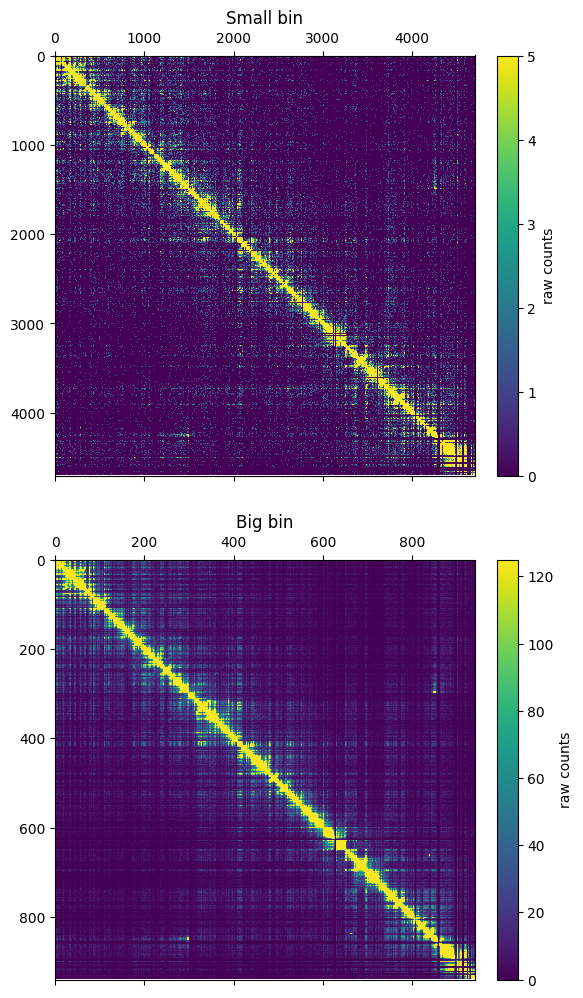

In [64]:
vmax = 5
f, ax = plt.subplots(2, 1, figsize=(7,6 * 2))

im_1 = ax[0].matshow(mtr_for_1, vmax=vmax)
plt.colorbar(im_1 ,fraction=0.046, pad=0.04, label='raw counts', ax=ax[0])
ax[0].xaxis.set_label_position('top')
ax[0].set_title('Small bin')

im_2 = ax[1].matshow(mtr_for_25, vmax=vmax*25)
plt.colorbar(im_2 ,fraction=0.046, pad=0.04, label='raw counts', ax=ax[1])
ax[1].xaxis.set_label_position('top')
ax[1].set_title('Big bin')

plt.show()

In [17]:
center_region = np.array(
    [
        (.2, .4),
        (.0, .6)
    ]
)

center_region = (center_region + 0.025)//0.05 * 0.05

def compute_scale_for_centers(areas):
    pass

In [ ]:
BIN = (250, 255)
WINDOW = 4

zomified = mtr_for_25[BIN[0] - WINDOW: BIN[0] + WINDOW + 1, BIN[1] - WINDOW: BIN[1] + WINDOW + 1]
sz = zomified.sum()
rz = mtr_for_1[
    (BIN[0] - WINDOW) * 5:(BIN[0] + WINDOW + 1)*5, (BIN[1] - WINDOW) * 5:(BIN[1] + WINDOW + 1)*5]
zoomed = (zomified, zoom=5, order=5)

In [19]:
tz = zoomed/zoomed.sum() * sz

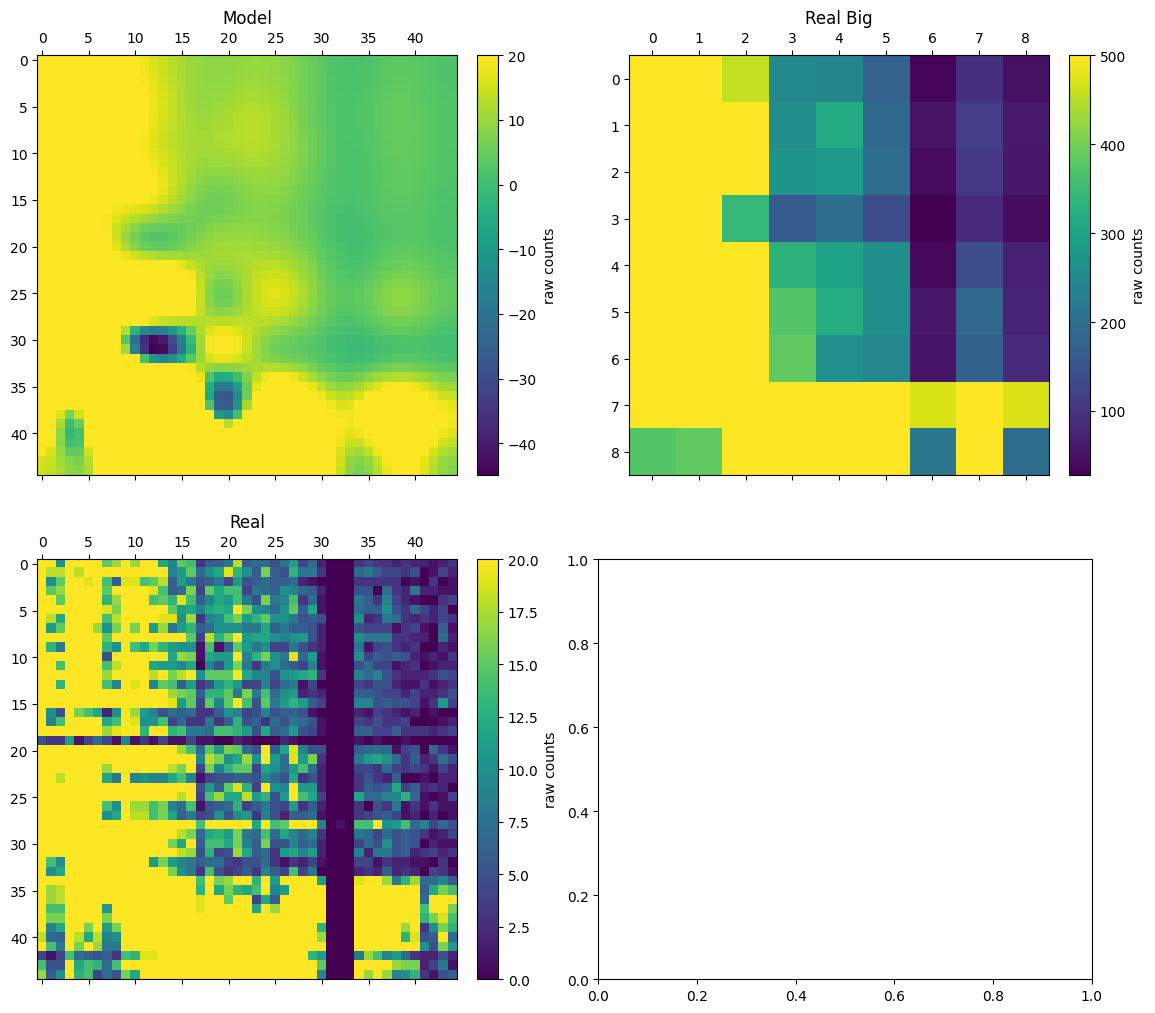

In [20]:
vmax = 20
f, ax = plt.subplots(2, 2, figsize=(7*2,6 * 2))

im_1 = ax[0][0].matshow(tz, vmax=vmax)
plt.colorbar(im_1 ,fraction=0.046, pad=0.04, label='raw counts', ax=ax[0][0])
ax[0][0].xaxis.set_label_position('top')
ax[0][0].set_title('Model')

im_2 = ax[1][0].matshow(rz, vmax=vmax)
plt.colorbar(im_2 ,fraction=0.046, pad=0.04, label='raw counts', ax=ax[1][0])
ax[1][0].xaxis.set_label_position('top')
ax[1][0].set_title('Real')

im_3 = ax[0][1].matshow(zomified, vmax=vmax*25)
plt.colorbar(im_3 ,fraction=0.046, pad=0.04, label='raw counts', ax=ax[0][1])
ax[0][1].xaxis.set_label_position('top')
ax[0][1].set_title('Real Big')


plt.show()

In [21]:
def fit_plane(counts):
    n, m = counts.shape
    assert n == m and n % 2 == 1
    A = []
    b = []
    for i in range(n):
        for j in range(n):
            x = i + 0.5  
            y = j + 0.5  
            A.append([x, y, 1])
            b.append(counts[i, j])
    A = np.array(A)
    b = np.array(b)
    coeffs, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)
    a, b_coef, c = coeffs
    return float(a), float(b_coef), float(c)


def integrate_plane(coeffs, region):
    a, b, c = coeffs
    x0, x1 = region[0]
    y0, y1 = region[1]
    I = a * (x1**2 - x0**2) / 2 * (y1 - y0) \
      + b * (y1**2 - y0**2) / 2 * (x1 - x0) \
      + c * (x1 - x0) * (y1 - y0)
    return I

def fit_plane_loglog(counts):
    n, m = counts.shape
    assert n == m and n % 2 == 1
    A, b = [], []
    for i in range(n):
        for j in range(n):
            x = i + 0.5
            y = j + 0.5
            A.append([np.log(x), np.log(y), 1])
            b.append(np.log(counts[i, j]))
    A = np.array(A)
    b = np.array(b)
    alpha, beta, gamma = np.linalg.lstsq(A, b, rcond=None)[0]
    return float(alpha), float(beta), float(gamma)

def integrate_powerlaw(coeffs, region):
    alpha, beta, gamma = coeffs
    C = np.exp(gamma)
    x0, x1 = region[0]
    y0, y1 = region[1]
    I = C * (x1**(alpha+1) - x0**(alpha+1)) / (alpha + 1) \
          * (y1**(beta+1) - y0**(beta+1)) / (beta + 1)
    return I

In [22]:
coeffs = fit_plane(zomified)

In [23]:
new_c = np.zeros(((WINDOW*2 + 1)*5, (WINDOW*2 + 1)*5))

for x_c, y_c in it.product(range((WINDOW*2 + 1)*5), range((WINDOW*2 + 1)*5)):
    int_value = integrate_plane(coeffs, ((x_c/5, x_c/5 + 0.2), (y_c/5, y_c/5 + 0.2)))
    full_sq_value = integrate_plane(coeffs, ((x_c//5, x_c//5 + 1), (y_c//5, y_c//5 + 1)))
    real_big_value = zomified[x_c//5, y_c//5]
    new_c[x_c, y_c] = real_big_value * (int_value/full_sq_value)

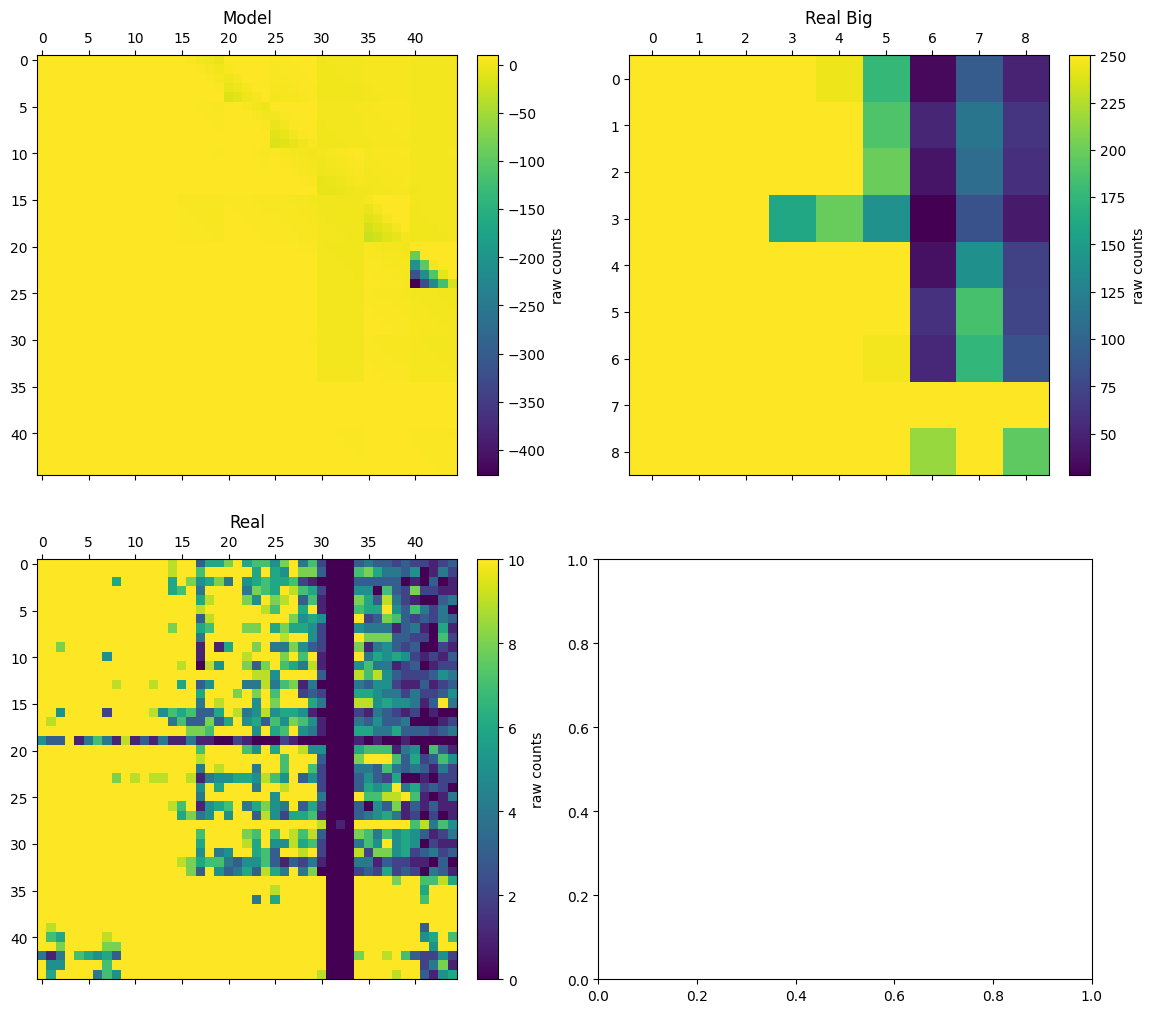

In [24]:
vmax = 10
f, ax = plt.subplots(2, 2, figsize=(7*2,6 * 2))

im_1 = ax[0][0].matshow(new_c, vmax=vmax)
plt.colorbar(im_1 ,fraction=0.046, pad=0.04, label='raw counts', ax=ax[0][0])
ax[0][0].xaxis.set_label_position('top')
ax[0][0].set_title('Model')

im_2 = ax[1][0].matshow(rz, vmax=vmax)
plt.colorbar(im_2 ,fraction=0.046, pad=0.04, label='raw counts', ax=ax[1][0])
ax[1][0].xaxis.set_label_position('top')
ax[1][0].set_title('Real')

im_3 = ax[0][1].matshow(zomified, vmax=vmax*25)
plt.colorbar(im_3 ,fraction=0.046, pad=0.04, label='raw counts', ax=ax[0][1])
ax[0][1].xaxis.set_label_position('top')
ax[0][1].set_title('Real Big')


plt.show()

In [25]:
coeffs = fit_plane_loglog(zomified)

In [ ]:
new_c_log = np.zeros(((WINDOW*2 + 1)*5, (WINDOW*2 + 1)*5))

for x_c, y_c in it.product(range((WINDOW*2 + 1)*5), repeat=2):
    x_lo = x_c/5
    y_lo = y_c/5
    x_hi = x_lo + 0.2
    y_hi = y_lo + 0.2

    int_value = integrate_powerlaw(coeffs, ((x_lo, x_hi), (y_lo, y_hi)))
    bx = x_c//5
    by = y_c//5
    full_sq_value = integrate_powerlaw(coeffs, ((bx, bx+1), (by, by+1)))
    
    real_big_value = zomified[bx, by]
    new_c_log[x_c, y_c] = real_big_value * (int_value / full_sq_value)

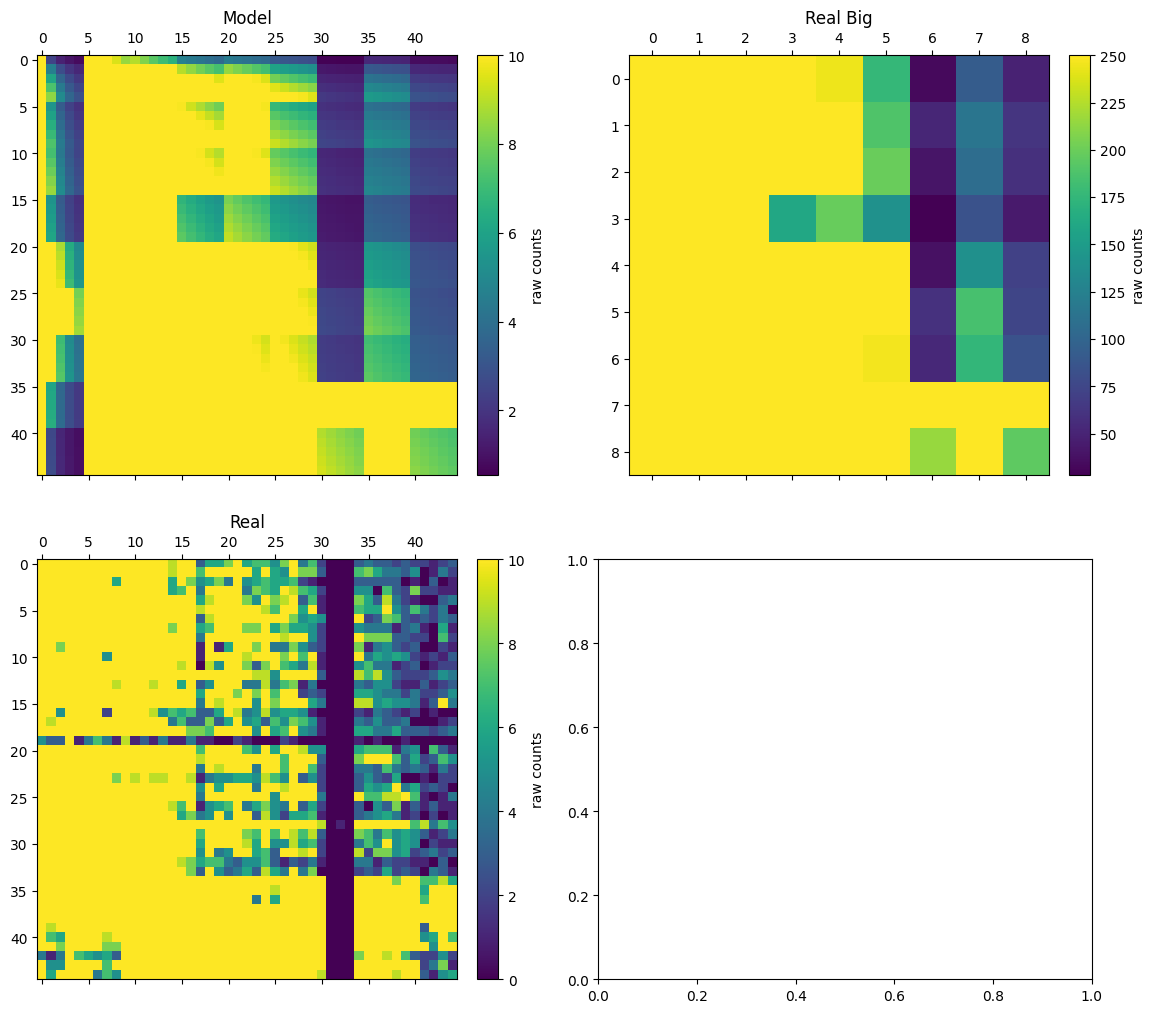

In [27]:
vmax = 10
f, ax = plt.subplots(2, 2, figsize=(7*2,6 * 2))

im_1 = ax[0][0].matshow(new_c_log, vmax=vmax)
plt.colorbar(im_1 ,fraction=0.046, pad=0.04, label='raw counts', ax=ax[0][0])
ax[0][0].xaxis.set_label_position('top')
ax[0][0].set_title('Model')

im_2 = ax[1][0].matshow(rz, vmax=vmax)
plt.colorbar(im_2 ,fraction=0.046, pad=0.04, label='raw counts', ax=ax[1][0])
ax[1][0].xaxis.set_label_position('top')
ax[1][0].set_title('Real')

im_3 = ax[0][1].matshow(zomified, vmax=vmax*25)
plt.colorbar(im_3 ,fraction=0.046, pad=0.04, label='raw counts', ax=ax[0][1])
ax[0][1].xaxis.set_label_position('top')
ax[0][1].set_title('Real Big')


plt.show()

In [30]:
from pairtools.lib.pairsio import read_pairs
import gzip

def open_maybe_gzip(filepath):
    if filepath.endswith('.gz'):
        return gzip.open(filepath, 'rt')  
    else:
        return open(filepath, 'r')
    

def read_pairs_full(path):
    pairs_df, header, chromsizes = read_pairs(path)
    pairs_polars = pl.from_pandas(pairs_df)
    return pairs_polars 


def remap_pairs(pairs_df, chains, old_border_shift=150, new_border_shift=150):

    overlapped_source_pairs = pb.overlap(
        df1=pairs_df.with_columns(
            pl.col('pos1').alias('pos_1_end')
        ),
        df2=chains.blocks.select(
                pl.col("name_chain_source").alias("chrom_source"),
                pl.col("start_aln_source").alias("start_source"),
                pl.col("end_aln_source").alias("end_source"),
                pl.col("name_chain_target").alias("chrom_target"),
                pl.col("start_aln_target").alias("start_target"),
                pl.col("end_aln_target").alias("end_target"),
                pl.col("strand_chain_target"),
                pl.col("strand_chain_source")
            ),
        suffixes=('_pairs', '_blocks'),
        cols2=('chrom1', 'pos1', 'pos_1_end'),
        cols1=('chrom_source', 'start_source', 'end_source'),
        output_type='polars.DataFrame'
    ).with_columns(
        pl.when(
            pl.col('strand_chain_target_pairs') == '+'
        ).then(
            pl.col('end_target_pairs') - (pl.col('end_source_blocks') - pl.col('pos1_pairs'))
        ).otherwise(
            pl.col('start_target_pairs') + (pl.col('end_source_blocks') - pl.col('pos1_pairs'))
        ).alias('pos_1_relocated'),

        pl.when(
            pl.col('strand_chain_target_pairs') == pl.col('strand1_blocks')
        ).then(
            pl.lit("+")
        ).otherwise(
            pl.lit("-")
        ).alias('strand_1_relocated')
    ).filter(
        (
            pl.when(
                pl.col('strand1_blocks') == '+'
            ).then(
                pl.col('end_source_blocks') - pl.col('pos1_pairs') >= old_border_shift
            ).otherwise(
                pl.col('pos1_pairs') - pl.col('start_source_blocks') >= old_border_shift
            )
        ) & (
            pl.when(
                pl.col('strand_1_relocated') == '+'
            ).then(
                pl.col('end_target_pairs') - pl.col('pos_1_relocated') >= new_border_shift
            ).otherwise(
                pl.col('pos_1_relocated') - pl.col('start_target_pairs') >= new_border_shift
            )
        )
    ).select(
        pl.col('pos_1_relocated'),
        pl.col('strand_1_relocated'),
        pl.col('chrom_target_pairs').alias('chrom_1_relocated'),

        pl.col('readid_blocks').alias('readid'),
        pl.col('pair_type_blocks').alias('pair_type'),
        pl.col('mapq1_blocks').alias('mapq1'),
        pl.col('mapq2_blocks').alias('mapq2'),

        pl.col('strand2_blocks').alias('strand2'),
        pl.col('chrom2_blocks').alias('chrom2'),
        pl.col('pos2_blocks').alias('pos2')
    )


    overlapped_target_pairs = pb.overlap(
        df1=overlapped_source_pairs.with_columns(
            pl.col('pos2').alias('pos_2_end')
        ),
        df2=chains.blocks.select(
                pl.col("name_chain_source").alias("chrom_source"),
                pl.col("start_aln_source").alias("start_source"),
                pl.col("end_aln_source").alias("end_source"),
                pl.col("name_chain_target").alias("chrom_target"),
                pl.col("start_aln_target").alias("start_target"),
                pl.col("end_aln_target").alias("end_target"),
                pl.col("strand_chain_target"),
                pl.col("strand_chain_source")
            ),
        suffixes=('_pairs', '_blocks'),
        cols2=('chrom2', 'pos2', 'pos_2_end'),
        cols1=('chrom_source', 'start_source', 'end_source'),
        output_type='polars.DataFrame'
    ).with_columns(
        pl.when(
            pl.col('strand_chain_target_pairs') == '+'
        ).then(
            pl.col('end_target_pairs') - (pl.col('end_source_blocks') - pl.col('pos2_pairs'))
        ).otherwise(
            pl.col('start_target_pairs') + (pl.col('end_source_blocks') - pl.col('pos2_pairs'))
        ).alias('pos_2_relocated'),

        pl.when(
            pl.col('strand_chain_target_pairs') == pl.col('strand2_blocks')
        ).then(
            pl.lit("+")
        ).otherwise(
            pl.lit("-")
        ).alias('strand_2_relocated')
    ).filter(
        (
            pl.when(
                pl.col('strand2_blocks') == '+'
            ).then(
                pl.col('end_source_blocks') - pl.col('pos2_pairs') >= old_border_shift
            ).otherwise(
                pl.col('pos2_pairs') - pl.col('start_source_blocks') >= old_border_shift
            )
        ) & (
            pl.when(
                pl.col('strand_2_relocated') == '+'
            ).then(
                pl.col('end_target_pairs') - pl.col('pos_2_relocated') >= new_border_shift
            ).otherwise(
                pl.col('pos_2_relocated') - pl.col('start_target_pairs') >= new_border_shift
            )
        )
    ).select(
        pl.col('readid_blocks').alias('readid'),
        pl.col('chrom_1_relocated_blocks').alias('chrom1'),
        pl.col('pos_1_relocated_blocks').alias('pos1'),
        pl.col('chrom_target_pairs').alias('chrom2'),
        pl.col('pos_2_relocated').alias('pos2'),
        pl.col('strand_1_relocated_blocks').alias('strand1'),
        pl.col('strand_2_relocated').alias('strand2'),
        pl.col('pair_type_blocks').alias('pair_type'),
        pl.col('mapq1_blocks').alias('mapq1'),
        pl.col('mapq2_blocks').alias('mapq2')
    )
    
    return overlapped_target_pairs

In [23]:
pairs_df = read_pairs_full('/Users/egorpitikov/Documents/osfstorage/adult_CNS1.dm3.nodups.pairs.gz')

In [24]:
pairs_df = pairs_df.slice(0, 10_000_000)

In [31]:
remapped = remap_pairs(pairs_df.rename({'readID': 'readid'}), a, old_border_shift=0, new_border_shift=0)

In [32]:
remapped


readid,chrom1,pos1,chrom2,pos2,strand1,strand2,pair_type,mapq1,mapq2
str,str,f64,str,f64,str,str,str,i64,i64
""".""","""chr2L""",5093.0,"""chr2L""",5262.0,"""+""","""+""","""UU""",4,60
""".""","""chr2L""",5096.0,"""chr2L""",5585.0,"""+""","""-""","""UU""",29,60
""".""","""chr2L""",5096.0,"""chr2L""",6651.0,"""+""","""+""","""UU""",26,60
""".""","""chr2L""",5096.0,"""chr2L""",1.755048e6,"""+""","""+""","""RU""",29,60
""".""","""chr2L""",5097.0,"""chr2L""",2.281103e6,"""+""","""+""","""UU""",44,60
…,…,…,…,…,…,…,…,…,…
""".""","""chr2L""",4.767699e6,"""chr2L""",4.792765e6,"""-""","""+""","""UU""",60,60
""".""","""chr2L""",4.7677e6,"""chr2L""",4.767857e6,"""+""","""-""","""UU""",60,60
""".""","""chr2L""",4.7677e6,"""chr2L""",4.771587e6,"""-""","""+""","""UU""",60,60


In [7]:
import time

def timeit_collect(times_list):
    def decorator(func):
        def wrapper(*args, **kwargs):
            total_time = 0
            start = time.perf_counter()
            result = func(*args, **kwargs)
            end = time.perf_counter()
            total_time += end - start
            times_list.append(total_time)
            return result
        return wrapper
    return decorator

In [8]:
lts = []
@timeit_collect(lts)
def fun():
    time.sleep(0.1)

In [9]:
for i in range(100):
    fun()

In [10]:
lts

[0.10130750000826083,
 0.10172570799477398,
 0.1050266670063138,
 0.10279566599638201,
 0.1050224160135258,
 0.10205245899851434,
 0.10501912501058541,
 0.10332591700716875,
 0.10374379201675765,
 0.10368062497582287,
 0.10502541597816162,
 0.10415945900604129,
 0.10502804099814966,
 0.10470320799504407,
 0.10501808300614357,
 0.10188624999136664,
 0.10207041699322872,
 0.10502062499290332,
 0.10243420899496414,
 0.10377854199032299,
 0.10332900000503287,
 0.10502512499806471,
 0.105021499999566,
 0.10502291601733305,
 0.10501424997346476,
 0.10487912502139807,
 0.10502437499235384,
 0.10329450000426732,
 0.10501941698021255,
 0.10330650000832975,
 0.10502229200210422,
 0.10270975000457838,
 0.10057804198004305,
 0.10501658302382566,
 0.10501875000772998,
 0.10501566698076203,
 0.10280779199092649,
 0.10049479198642075,
 0.10124429198913276,
 0.10501874997862615,
 0.1048430829832796,
 0.1030284590087831,
 0.10072404201491736,
 0.10201629198854789,
 0.10502300001098774,
 0.1013960000127

In [64]:
pl.DataFrame(
    {
        'a': [1, 2, 3, 1, 2, 3, 1, 2, 3],
        'b': [1, 2, 1, 2, 1, 2, 1, 2, 1]
    }
).unique()

a,b
i64,i64
3,2
1,2
1,1
2,2
2,1
3,1


In [76]:
from numba import njit, prange

In [78]:
@njit(parallel=True, nopython=True, nogil=True)
def fit_plane(counts):
    A = np.zeros(counts.shape, dtype=np.float32)
    b = np.zeros(counts.shape, dtype=np.float32)
    for i in prange(counts.shape[0]):
        for j in prange(counts.shape[1]):
            x = i + 0.5  
            y = j + 0.5  
            A[i, j] = x + y
            b[i, j] = counts[i, j]
    coeffs, residuals, rank, s = np.linalg.lstsq(A, b, rcond=None)
    a, b_coef, c = coeffs
    return float(a), float(b_coef), float(c)

def integrate_plane(coeffs, region):
    a, b, c = coeffs
    x0, x1 = region[0]
    y0, y1 = region[1]
    I = a * (x1**2 - x0**2) / 2 * (y1 - y0) + b * (y1**2 - y0**2) / 2 * (x1 - x0) + c * (x1 - x0) * (y1 - y0)
    return I

class Regression2D:
    def __init__(self, is_log=False):
        self.is_log = is_log
        self.__coeffs = None

    def fit(self, counts):
        if self.is_log:
            self.__coeffs = fit_plane_loglog(counts)
        else:
            self.__coeffs = fit_plane(counts)
    
    @property
    def coeffs(self):   
        return {'a': self.__coeffs[0], 'b': self.__coeffs[1], 'c': self.__coeffs[2]}

/Users/egorpitikov/Documents/pets/liftover_2d/.venv/lib/python3.12/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [ ]:
import numpy as np
from numba import njit, prange

@njit(parallel=True, nogil=True)
def fit_plane(counts):
    n, m = counts.shape
    Sxx = Syy = Sxy = Sx = Sy = S1 = 0.0
    Sxz = Syz = Sz = 0.0

    for i in prange(n):
        for j in range(m):
            x = i + 0.5
            y = j + 0.5
            z = counts[i, j]

            Sxx += x * x
            Syy += y * y
            Sxy += x * y
            Sx  += x
            Sy  += y
            S1  += 1.0

            Sxz += x * z
            Syz += y * z
            Sz  += z

    ATA = np.array([
        [Sxx, Sxy, Sx],
        [Sxy, Syy, Sy],
        [Sx,  Sy,  S1]
    ], dtype=np.float64)

    ATb = np.array([Sxz, Syz, Sz], dtype=np.float64)

    coeffs = np.linalg.solve(ATA, ATb)
    return coeffs[0], coeffs[1], coeffs[2]


In [86]:
fit_plane(randomizer)

(-0.010840652985306246, -0.003981305185696609, 0.5532204020102777)

In [91]:
import numpy as np

def fit_plane(counts):
    n, m = counts.shape
    x_coords, y_coords = np.meshgrid(
        np.arange(n) + 0.5,
        np.arange(m) + 0.5,
        indexing="ij"
    )
    X = np.column_stack([
        x_coords.ravel(),
        y_coords.ravel(),
        np.ones(n * m)
    ])
    y = counts.ravel()

    coeffs, *_ = np.linalg.lstsq(X, y, rcond=None)
    return coeffs[0], coeffs[1], coeffs[2]


In [92]:
fit_plane(randomizer)

(np.float64(-0.010840652985306247),
 np.float64(-0.0039813051856965286),
 np.float64(0.5532204020102774))

In [4]:
import numpy as np

In [ ]:
Empty window for row {'row_number': 79068, 'bin1_id': 2302, 'bin2_id': 10062, 'source_bin_1_region_rate': [0.0, 0.7505], 'source_bin_2_region_rate': [0.0, 0.4033]}
bbox (np.uint64(2302), np.uint64(4416), np.uint64(9663), np.uint64(11905))

In [11]:
bbox = (np.uint64(2302), np.uint64(4416), np.uint64(9663), np.uint64(11905))
bin1 = 2302
bin2 = 10062
window_size=5

scs = (bbox[1]  - bbox[0], bbox[3] - bbox[2])

In [17]:
loc_hor = int(bin1) - int(bbox[0])
loc_ver = int(bin2) - int(bbox[2])

start_i = max(0, loc_hor - window_size)
end_i   = min(scs[0], loc_hor + window_size + 1)
start_j = max(0, loc_ver - window_size)
end_j   = min(scs[1], loc_ver + window_size + 1)

In [18]:
(start_i,end_i), (start_j,end_j)

((0, 6), (394, 405))

In [ ]:
def __calculate_small_window(bin1, bin2, sparse_contacts, window_size, bbox):
        loc_hor = bin1 - bbox[0]
        loc_ver = bin2 - bbox[2]

        start_i = max(0, loc_hor - window_size)
        end_i   = min(sparse_contacts.shape[0], loc_hor + window_size + 1)
        start_j = max(0, loc_ver - window_size)
        end_j   = min(sparse_contacts.shape[1], loc_ver + window_size + 1)
        
        window = sparse_contacts[start_i:end_i, start_j:end_j]
        location_in_window = (loc_hor - start_i, loc_ver - start_j)
        
        return window.toarray(), location_in_window

In [20]:
import h5py

with h5py.File("/Users/egorpitikov/Downloads/YueLab-muscle-HiC.danRer10.mapq_30.1000.mcool", "r") as f:
    print(list(f["resolutions"].keys()))

['1000']


In [21]:
from src.readers import read_cooler_square

In [22]:
?read_cooler_square

Signature:
read_cooler_square(
    cooler_file: Union[cooler.api.Cooler, str],
    square_size: int = 700,
    square_overlap: int = 5,
    chunk_size=None,
) -> Iterator[Tuple[Tuple[int, int, int, int], src.readers.cooler_reader.CoolerPolars]]
Docstring: <no docstring>
File:      ~/Documents/pets/liftover_2d/src/readers/cooler_reader.py
Type:      function

In [25]:
import cooler

In [41]:
clr = cooler.Cooler(f'/Users/egorpitikov/Downloads/YueLab-muscle-HiC.danRer10.mapq_30.1000.mcool::resolutions/1000')

In [44]:
ii = 0 
for bbox_now, clr_readed in read_cooler_square(
    clr,
    square_overlap=10
):
    min_1_bin, max_1_bin, min_2_bin, max_2_bin = bbox_now
    if min_1_bin != 0:
        min_1_bin += 5
    if max_1_bin != clr.info['nbins']:
        max_1_bin -= 6
    if min_2_bin != 0:
        min_2_bin += 5      
    if max_2_bin != clr.info['nbins']:
        max_2_bin -= 6

    print(min_1_bin, max_1_bin, min_2_bin, max_2_bin)
    ii += 1
    if ii > 50:
        break

0 694 0 694
0 694 695 1384
0 694 1385 2074
0 694 2075 2764
0 694 2765 3454
0 694 3455 4144
0 694 4145 4834
0 694 4835 5524
0 694 5525 6214
0 694 6215 6904
0 694 6905 7594
0 694 7595 8284
0 694 8285 8974
0 694 8975 9664
0 694 9665 10354
0 694 10355 11044
0 694 11045 11734
0 694 11735 12424
0 694 12425 13114
0 694 13115 13804
0 694 13805 14494
0 694 14495 15184
0 694 15185 15874
0 694 15875 16564
0 694 16565 17254
0 694 17255 17944
0 694 17945 18634
0 694 18635 19324
0 694 19325 20014
0 694 20015 20704
0 694 20705 21394
0 694 21395 22084
0 694 22085 22774
0 694 22775 23464
0 694 23465 24154
0 694 24155 24844
0 694 24845 25534
0 694 25535 26224
0 694 26225 26914
0 694 26915 27604
0 694 27605 28294
0 694 28295 28984
0 694 28985 29674
0 694 29675 30364
0 694 30365 31054
0 694 31055 31744
0 694 31745 32434
0 694 32435 33124
0 694 33125 33814
0 694 33815 34504
0 694 34505 35194


In [37]:
?read_cooler_square

Signature:
read_cooler_square(
    cooler_file: Union[cooler.api.Cooler, str],
    square_size: int = 700,
    square_overlap: int = 5,
    chunk_size=None,
) -> Iterator[Tuple[Tuple[int, int, int, int], src.readers.cooler_reader.CoolerPolars]]
Docstring: <no docstring>
File:      ~/Documents/pets/liftover_2d/src/readers/cooler_reader.py
Type:      function

In [47]:
(1_400_000_000 / 1000)**2

1960000000000.0

In [49]:
cooler.Cooler(
    '/Users/egorpitikov/Documents/big_sasha_test/tmp7rapuno8.multi.cool copy'
)

KeyError: "No cooler found at: /Users/egorpitikov/Documents/big_sasha_test/tmp7rapuno8.multi.cool copy. Coolers found in ['/0', '/1', '/2', '/3', '/4', '/5', '/6', '/7', '/8', '/9', '/10', '/11', '/12', '/13', '/14', '/15', '/16', '/17', '/18', '/19', '/20', '/21', '/22', '/23', '/24', '/25', '/26', '/27', '/28', '/29', '/30', '/31', '/32', '/33', '/34', '/35', '/36', '/37', '/38', '/39', '/40', '/41', '/42', '/43', '/44', '/45', '/46', '/47', '/48', '/49', '/50', '/51', '/52', '/53', '/54', '/55', '/56', '/57', '/58', '/59', '/60', '/61', '/62', '/63', '/64', '/65', '/66', '/67', '/68', '/69', '/70', '/71', '/72', '/73', '/74', '/75']. Use '::' to specify a group path"

In [19]:
import numpy as np
from numba import njit

@njit
def bspline_weight(x, order):
    ax = abs(x)
    if order == 1:  # линейный
        return np.maximum(1 - ax, 0.0)
    elif order == 2:  # квадратичный
        if ax < 0.5:
            return 0.75 - ax * ax
        elif ax < 1.5:
            return 0.5 * (ax - 1.5)**2
        else:
            return 0.0
    elif order == 3:  # кубический
        if ax < 1:
            return (4 - 6 * ax * ax + 3 * ax**3) / 6
        elif ax < 2:
            return (2 - ax)**3 / 6
        else:
            return 0.0
    elif order == 4:  # бикубический (катмулл-ром)
        if ax < 1:
            return (1.5*ax**4 - 2.5*ax**2 + 1)
        elif ax < 2:
            return (-0.5*ax**4 + 2.5*ax**3 - 4*ax**2 + 2*ax)
        else:
            return 0.0
    else:
        # для больших order можно добавить рекурсивное вычисление
        return 0.0


@njit
def make_bspline_kernel(n, scale, order):
    """
    Возвращает ядро размера (2n+1, 2n+1, scale, scale),
    которое можно применять как свёртку для апсемплинга.
    """
    size = 2 * n + 1
    kernel = np.zeros((scale, scale, size, size), dtype=np.float32)
    xs = np.arange(-n, n + 1)

    for i in range(scale):
        fx = (i / scale)
        for j in range(scale):
            fy = (j / scale)
            for xi in range(size):
                wx = bspline_weight(xs[xi] - fx, order)
                for yi in range(size):
                    wy = bspline_weight(xs[yi] - fy, order)
                    kernel[i, j, xi, yi] = wx * wy
    return kernel

@njit
def upscale_patch(patch, kernel):
    scale = kernel.shape[0]
    out = np.zeros((scale, scale), dtype=np.float32)
    for i in range(scale):
        for j in range(scale):
            acc = 0.0
            for xi in range(patch.shape[0]):
                for yi in range(patch.shape[1]):
                    acc += patch[xi, yi] * kernel[i, j, xi, yi]
            out[i, j] = acc
    return out


In [26]:
kernel = make_bspline_kernel(5, 2, 5)

In [27]:
kernel

array([[[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
         [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
        

In [25]:
patch = np.random.rand(5, 5).astype(np.float32)

In [21]:
upscaled = upscale_patch(patch, kernel)

In [23]:
patch

array([[0.4659305 , 0.7414433 , 0.07666127, 0.35793445, 0.5406068 ],
       [0.7729561 , 0.78221345, 0.02840702, 0.12296295, 0.6737346 ],
       [0.66068554, 0.25926903, 0.76764977, 0.03072028, 0.167096  ],
       [0.36306912, 0.28302926, 0.39519337, 0.4339915 , 0.74081546],
       [0.802106  , 0.8639989 , 0.07703744, 0.8814406 , 0.34332618]],
      dtype=float32)

In [22]:
upscaled

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]], dtype=float32)

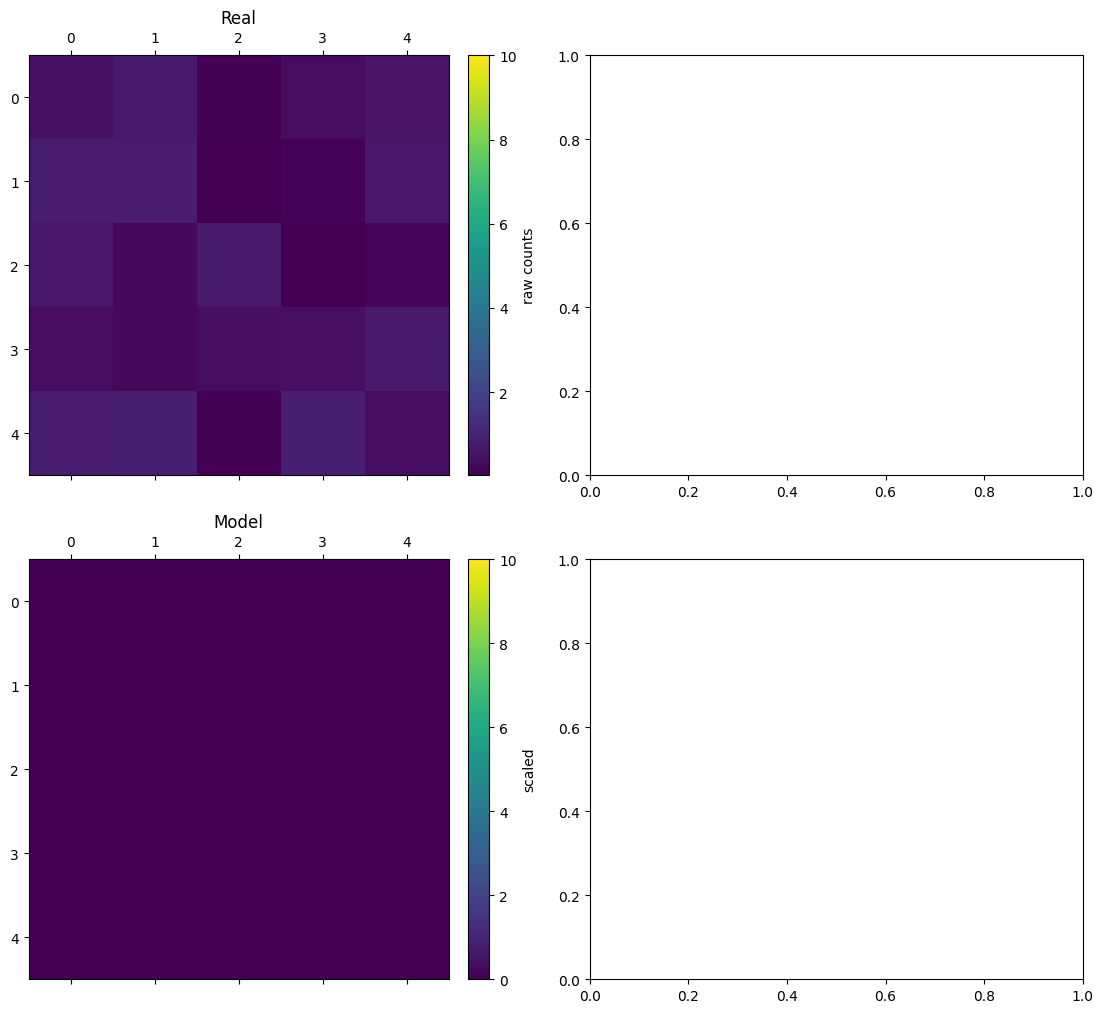

In [18]:
vmax = 10
f, ax = plt.subplots(2, 2, figsize=(7*2,6 * 2))

im_1 = ax[0][0].matshow(patch, vmax=vmax)
plt.colorbar(im_1 ,fraction=0.046, pad=0.04, label='raw counts', ax=ax[0][0])
ax[0][0].xaxis.set_label_position('top')
ax[0][0].set_title('Real')

im_2 = ax[1][0].matshow(upscaled, vmax=vmax)
plt.colorbar(im_2 ,fraction=0.046, pad=0.04, label='scaled', ax=ax[1][0])
ax[1][0].xaxis.set_label_position('top')
ax[1][0].set_title('Model')


plt.show()

In [1]:
zoom 

NameError: name 'zoom' is not defined

In [4]:
from scipy.ndimage import zoom
import numpy as np

In [8]:
zoom(np.arange(25).reshape(5, 5), zoom=5, order=5)

array([[ 0,  0,  0,  0,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,
         3,  3,  3,  3,  3,  4,  4,  4,  4],
       [ 0,  0,  0,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  3,
         3,  3,  3,  3,  4,  4,  4,  4,  4],
       [ 1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  3,  3,  3,  3,  3,
         3,  4,  4,  4,  4,  4,  5,  5,  5],
       [ 2,  2,  2,  2,  2,  2,  3,  3,  3,  3,  3,  3,  4,  4,  4,  4,
         4,  4,  5,  5,  5,  5,  5,  6,  6],
       [ 3,  3,  3,  3,  3,  3,  4,  4,  4,  4,  4,  5,  5,  5,  5,  5,
         5,  5,  6,  6,  6,  6,  7,  7,  7],
       [ 4,  4,  4,  4,  4,  5,  5,  5,  5,  5,  6,  6,  6,  6,  6,  6,
         6,  7,  7,  7,  7,  8,  8,  8,  8],
       [ 5,  5,  5,  5,  6,  6,  6,  6,  6,  7,  7,  7,  7,  7,  7,  7,
         8,  8,  8,  8,  8,  9,  9,  9,  9],
       [ 6,  6,  6,  6,  7,  7,  7,  7,  8,  8,  8,  8,  8,  8,  8,  9,
         9,  9,  9,  9, 10, 10, 10, 10, 10],
       [ 7,  7,  7,  7,  8,  8,  8,  8,  9,  9,  9,  9,  9,  9, 